In [1]:
1250080179 % 23

3

## Import library

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Load data

In [3]:
df = pd.read_csv('data/Car_Tyres_Dataset.csv')
df.head()


,Brand,Model,Submodel,Tyre Brand,Serial No.,Type,Load Index,Size,Selling Price,Original Price,Rating
0,Maruti,Swift Dzire,LDI (Diesel),JKTyre,Taximaxx,Tubeless,85,165/80 R 14,"3,255","3,255",5.0
1,Maruti,Swift Dzire,LDI (Diesel),CEAT,Milage X3,Tubeless,85,165/80 R 14,"3,406","3,406",4.0
2,Maruti,Swift Dzire,LDI (Diesel),Apollo,Amazer 4G Life,Tubeless,85,165/80 R 14,"3,490","4,319",4.5
3,Maruti,Swift Dzire,LDI (Diesel),Continental,Comfort Contact CC6,Tubeless,85,165/80 R 14,"4,484","4,244",NaN
4,Maruti,Swift Dzire,LDI (Diesel),GoodYear,Assurance Duraplus 2,Tubeless,85,165/80 R 14,"3,025","3,025",4.2


## Check null data

In [4]:
df.isna().sum()

Brand                0
Model                0
Submodel             0
Tyre Brand           0
Serial No.           0
Type                 0
Load Index           0
Size                 0
Selling Price        0
Original Price       0
Rating            2102
dtype: int64

In [5]:
df['Rating'].value_counts()

Rating
5.0    827
4.0    543
3.0    192
4.5    113
4.2     73
3.7     59
4.6     57
3.6     55
3.8     54
4.7     52
4.8     47
3.9     42
2.8     34
4.1     19
4.4     19
3.5     15
2.0     15
4.3     12
2.9      9
2.7      6
1.9      3
3.3      2
Name: count, dtype: int64

## Preprocessing

In [6]:
df_drop = df.dropna().copy()

In [7]:
for col in ['Brand ', 'Model', 'Submodel', 'Tyre Brand', 'Type', 'Size']:
    display(df_drop[col].value_counts())

Brand 
Maruti    2248
Name: count, dtype: int64

Model
Ciaz                421
Ertiga              224
Alto                154
Ritz                147
Swift Dzire         132
New Swift (2018)    122
Dzire               120
Esteem               91
Omni                 84
Swift Dzire 2008     84
Alto K10             80
Celerio              77
Eeco                 64
SX4                  61
A-Star               55
Vitara Brezza        50
Swift                40
Celerio X            40
Wagon R              36
Swift Deca           32
Swift                30
Stingray             28
Baleno               21
Fronx                21
Zen Estilo           16
Swift                 5
800                   4
Grand Vitara          3
Gypsy                 3
Zen                   2
Zen                   1
Name: count, dtype: int64

Submodel
ZDI (Diesel)                       94
LDI (Diesel)                       85
Diesel ZDi +                       65
Vxi(Petrol)                        59
LXI (Petrol)                       55
                                   ..
2.4 MT (Petrol)                     1
King Soft Top MPI(Petrol)           1
King Hard Top Ambulance(Petrol)     1
King Hard Top MPI(Petrol)           1
2.4 AT (Petrol)                     1
Name: count, Length: 164, dtype: int64

Tyre Brand
BridgeStone    461
CEAT           343
Apollo         260
GoodYear       225
Yokohama       204
MRF            186
JKTyre         176
Michelin       104
Falken          94
UltraMile       66
Pirelli         65
Continental     58
Firestone        6
Name: count, dtype: int64

Type
Tubeless    2140
Tube         108
Name: count, dtype: int64

Size
185/65 R 15    766
165/80 R 14    455
145/80 R 12    231
155/80 R 13    153
195/55 R 16    115
165/70 R 14     90
155/65 R 13     70
155 R 13        64
205/60 R 16     58
155/65 R 14     48
185/70 R 14     35
215/60 R 16     32
145/70 R 13     29
145/80 R 13     23
195/65 R 15     21
175/70 R 13     20
185/65 R 14     12
185/70 R 19      3
225/65 R 17      3
205/70 R 16      3
185/70 R 20      3
185/70 R14       2
185/70 R 15      1
185/70 R 24      1
185/70 R 26      1
185/70 R 28      1
185/70 R 29      1
185/70 R 25      1
185/70 R 16      1
185/70 R 21      1
145/70 R 19      1
145/70 R 15      1
145/70 R 12      1
145/70 R 20      1
Name: count, dtype: int64

In [8]:
df_drop.drop(columns=['Serial No.', 'Selling Price', 'Original Price', 'Submodel'], inplace=True)


In [9]:
df_drop = pd.get_dummies(data=df_drop, columns=['Brand ', 'Model', 'Tyre Brand', 'Type', 'Size'], dtype=int, drop_first=True)

## Split data to train vs test

In [10]:
X = df_drop.drop(columns='Rating')
y = df_drop['Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026)

In [11]:
df_drop.describe()

,Load Index,Rating,Model_A-Star,Model_Alto,Model_Alto K10,Model_Baleno,Model_Celerio,Model_Celerio X,Model_Ciaz,Model_Dzire,...,Size_185/70 R 26,Size_185/70 R 28,Size_185/70 R 29,Size_185/70 R14,Size_195/55 R 16,Size_195/65 R 15,Size_205/60 R 16,Size_205/70 R 16,Size_215/60 R 16,Size_225/65 R 17
count,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,...,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000,2248.000000
mean,84.199288,4.297598,0.024466,0.068505,0.035587,0.009342,0.034253,0.017794,0.187278,0.053381,...,0.000445,0.000445,0.000445,0.000890,0.051157,0.009342,0.025801,0.001335,0.014235,0.001335
std,5.839140,0.698433,0.154526,0.252667,0.185300,0.096221,0.181918,0.132230,0.390221,0.224842,...,0.021091,0.021091,0.021091,0.029821,0.220366,0.096221,0.158576,0.036515,0.118484,0.036515
min,69.000000,1.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,81.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,86.000000,4.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,88.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,102.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Build model

In [12]:
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.14727131144500905, 0.11426555283646911)

In [13]:
df_coef = pd.DataFrame({
    'features': X.columns,
    'coef': lg.coef_,
    'coefAbs': abs(lg.coef_)
}).sort_values(by='coefAbs', ascending=False)
df_coef


,features,coef,coefAbs
46,Size_145/70 R 19,1.924167e+00,1.924167e+00
47,Size_145/70 R 20,1.625298e+00,1.625298e+00
75,Size_215/60 R 16,-1.161154e+00,1.161154e+00
62,Size_185/70 R 19,-8.484169e-01,8.484169e-01
26,Model_Vitara Brezza,-8.304878e-01,8.304878e-01
...,...,...,...
5,Model_Celerio,6.847540e-03,6.847540e-03
64,Size_185/70 R 21,2.220446e-16,2.220446e-16
29,Model_Zen,-1.387779e-16,1.387779e-16
68,Size_185/70 R 28,0.000000e+00,0.000000e+00


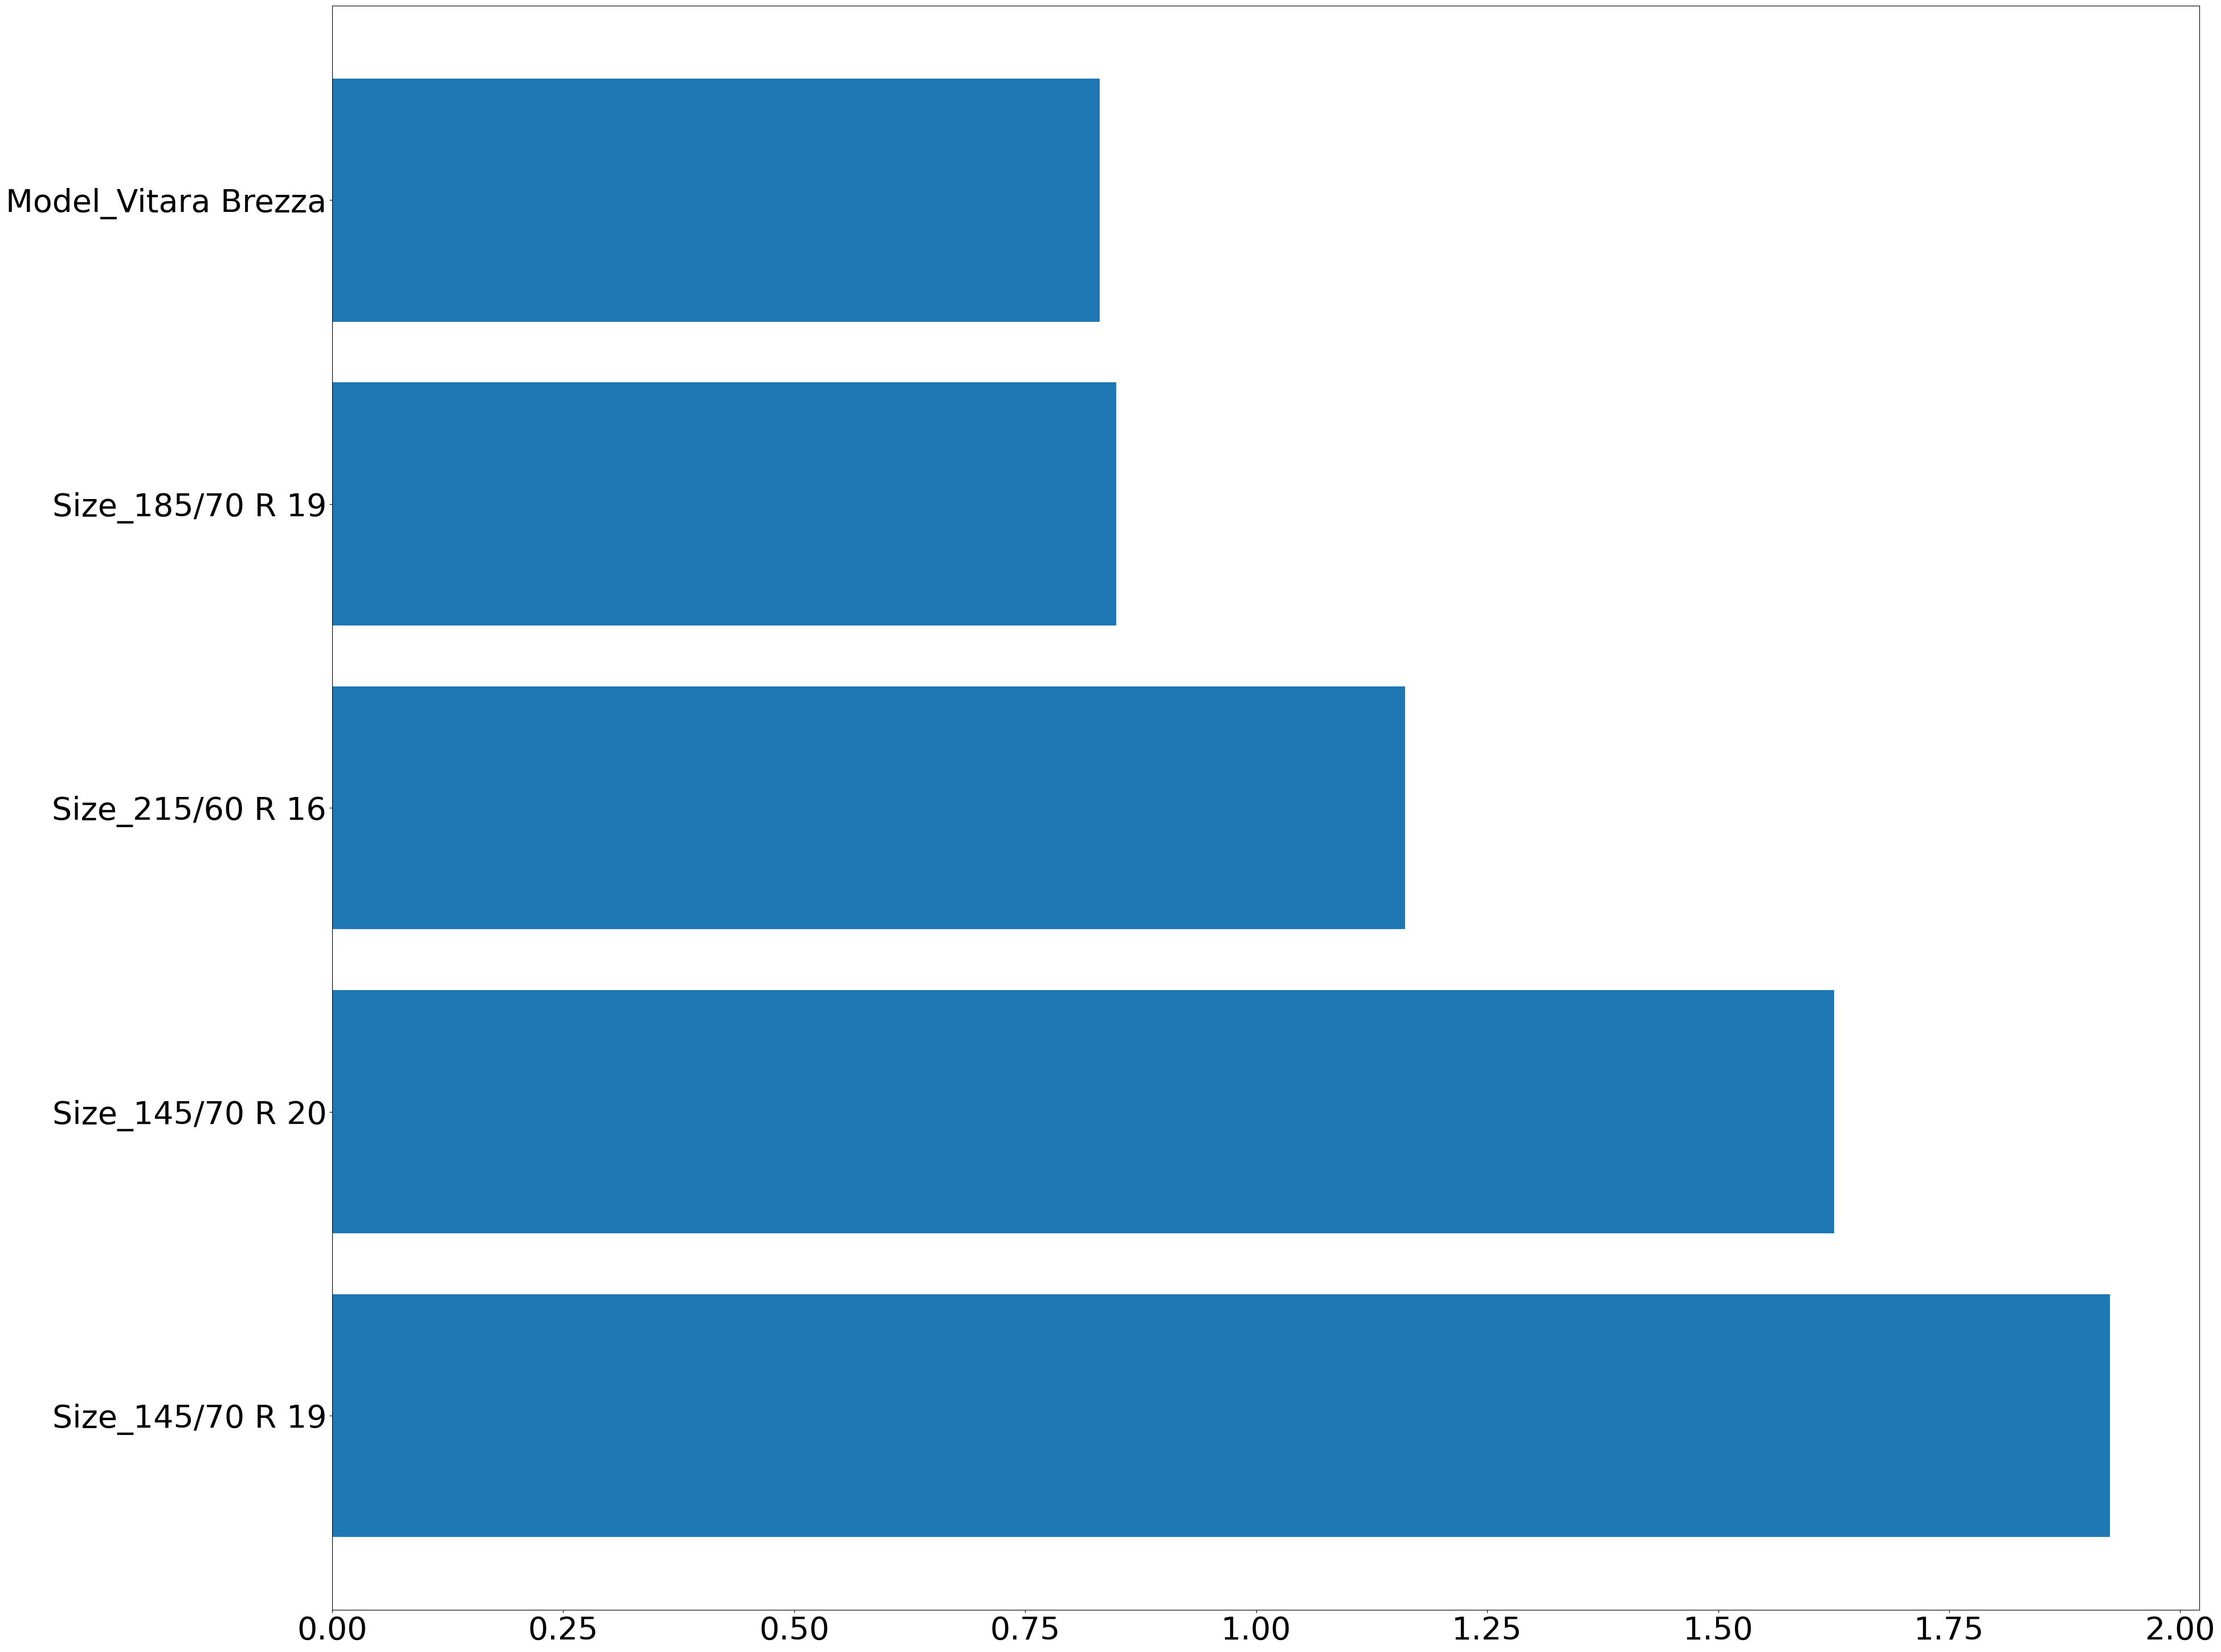

In [14]:
plt.rcParams['font.size'] = 40
plt.figure(figsize=(40, 30))
plt.barh(y=df_coef['features'].head(5), width=df_coef['coefAbs'].head(5))
plt.tight_layout()
plt.show()

## Predict

In [15]:
predict_train = lg.predict(X_train)
predict_test = lg.predict(X_test)

## Mean squared error

In [16]:
mean_squared_error(y_train, predict_train), mean_squared_error(y_test, predict_test)

(0.4154720323749804, 0.432795935747305)

In [17]:
r2_score(y_train, predict_train), r2_score(y_test, predict_test)

(0.14727131144500905, 0.11426555283646911)

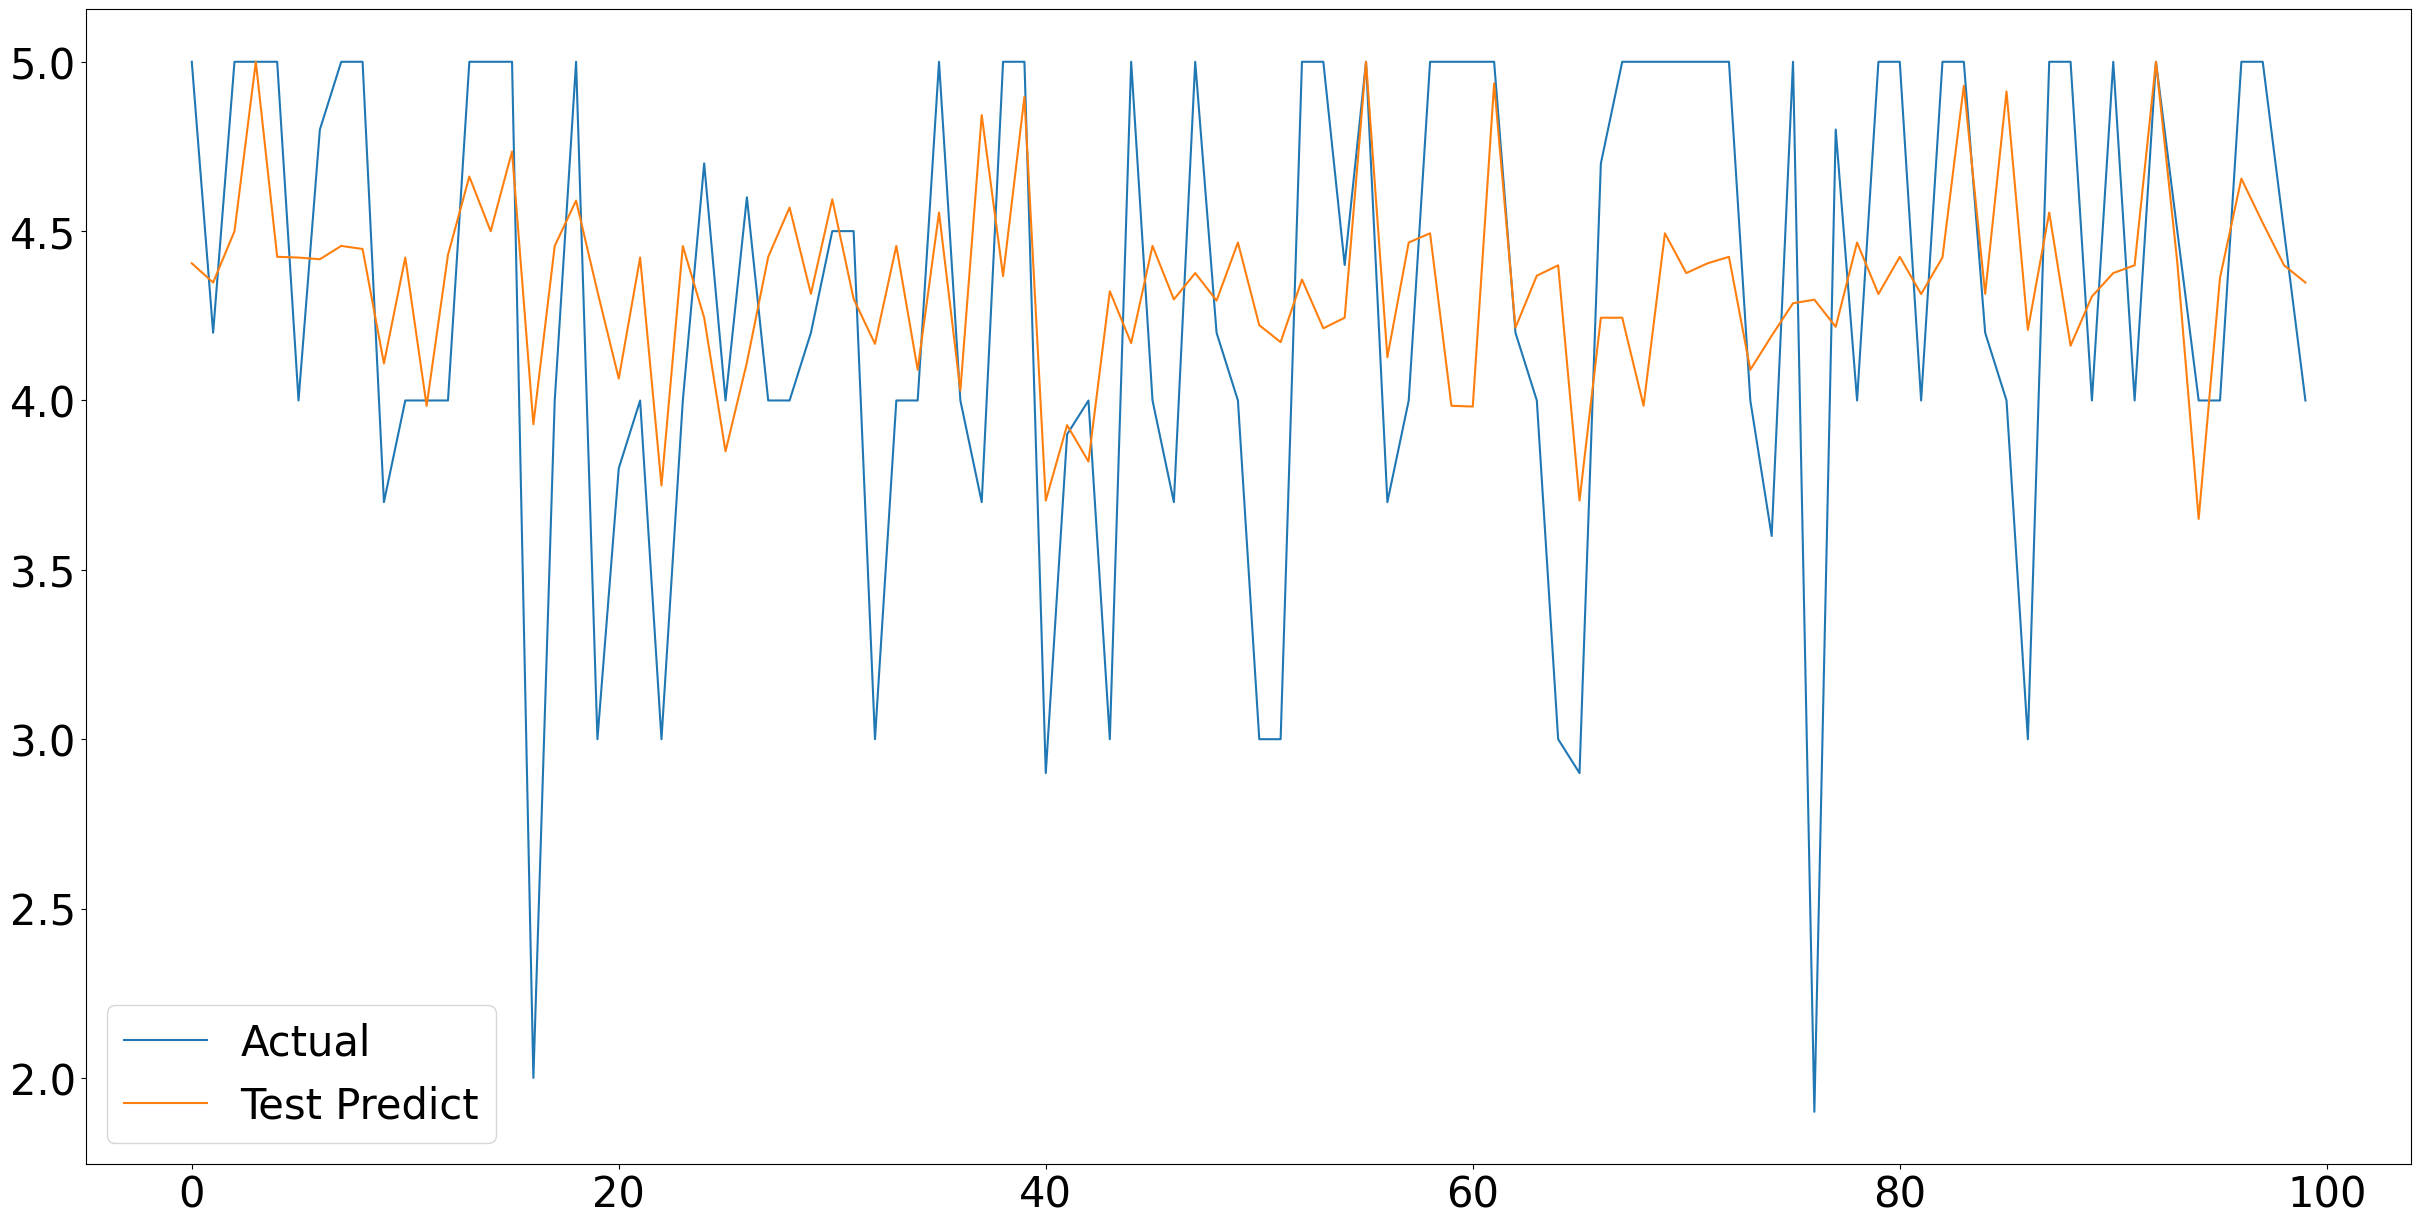

In [18]:
plt.rcParams['font.size'] = 30
plt.figure(figsize=(30, 15))
pd.Series(y_test).reset_index(drop=True).head(100).plot()
pd.Series(predict_test).head(100).plot()
plt.legend(['Actual', 'Test Predict'])
plt.show()
